# The IPO Birthday Effect — do stocks pop on their listing anniversary? 🎂
### Testing a piece of market folklore, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Companies celebrate the anniversary of the day they went public — press writes 'one year on the market' retrospectives, analysts run their calendar notes, and the folklore says all that **attention** should give the stock a little bump around its **IPO birthday** each year. If true, you could buy just before the anniversary and sell just after, every year, on any listed company.

So we test it the honest way: take 30 well-known US IPOs, and for every year each one has been public, look at how it did around its birthday *versus the market* — the 'abnormal return'. Then we check whether a **random** date does any worse.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the event-study maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ipo_birthday import data, strategy as st

PRE, POST = 5, 5

def load_real():
    """Cache-first real abnormal-return frame + IPO dates (empty offline)."""
    px = data.fetch_prices(fetch=False)
    if px.empty:
        return None, None
    ar = st.abnormal_returns(px)
    return ar, data.ipo_dates()

AR, IPOS = load_real()
HAVE_REAL = AR is not None
print("real IPO-birthday tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({AR.shape[1]} names, {AR.index[0].date()} -> {AR.index[-1].date()})")


real IPO-birthday tape present: True (30 names, 1997-01-02 -> 2026-06-26)


## The answer first 🎯

| Question | Answer |
|---|---|
| Do stocks pop on their IPO birthday? | **No.** Over **312 firm-years** the average abnormal return in the 11-day window around the anniversary is **+62.75 basis points** (that's 0.63%), with a *t* of just **1.36** — well below the 'real' bar of 2. |
| Is that tiny bump even real? | **No** — half the birthdays (50.6%) were actually *negative*, and the median was a rounding-error **+12.0 bps**. |
| Could it be luck? | Worse than luck. A **random** date (not the birthday) did *better* on average (+86.23 bps) — so the birthday window is nothing special (*p* = 0.648). |
| Could you trade it? | **No.** The 'effect' is just that these famous survivors beat the market in general — you'd see it in *any* window, birthday or not. |

> The bump you *do* see is a mirage: this basket is winners that are still around in 2026, so they beat the market on average — and that shows up on random dates just as much as on birthdays.

## 1 · The claim

> *"A stock earns a little extra around the anniversary of its IPO — a 'birthday effect' from renewed attention."*

The idea rides on a real behavioural finding: **attention moves prices** (Barber & Odean 2008; Da, Engelberg & Gao 2011). An IPO anniversary is a natural attention magnet — 'one year since the float' headlines, calendar reminders, retrospective coverage. If that attention nudges buyers in, the stock should drift up a touch around the date.

## 2 · So what?

If it were real it would be a rare *free* calendar trade: the anniversary is perfectly predictable years in advance, and it applies to *every* listed company. But that is exactly why we should be suspicious — a date everyone can see coming is a date the market has already priced. The desk has looked at the IPO *launch* pop ([219 IPO-Pop](../../219-ipo-pop/)); here we go after the *recurring birthday*.

## 3 · How would we even know?

1. **Pick a birthday.** Each company's IPO date is public. Its 1st, 2nd, 3rd… anniversary are just that date in later years.
2. **Measure the window.** Around each anniversary, add up the stock's return **minus the market's** (SPY) over an 11-day window (5 days before to 5 after). That's its 'abnormal return' — how much it beat the market *that week*.
3. **Average over everything.** 30 companies × up-to-~29 years of birthdays = hundreds of events. If birthdays pay, the average should be clearly positive.
4. **The catch.** Compare against **random** dates. If random dates do just as well, the birthday isn't special.

*Timing:* the window is fixed by the (known) calendar date — nothing about the future leaks in.

## 4 · The teardown — let's actually look

**How big is the average birthday bump, and how does it compare to a random date?**

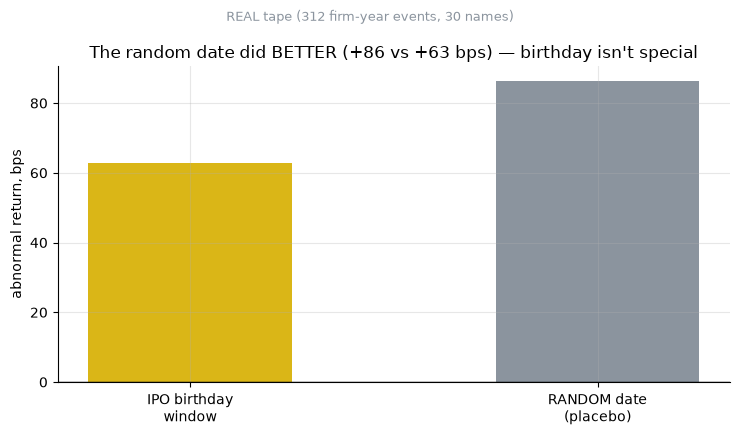

birthday CAR +62.7 bps (t +1.36) vs random +86.2 bps -> placebo p 0.648


In [2]:
if HAVE_REAL:
    cars = st.event_cars(AR, IPOS, PRE, POST); t = st.car_tstat(cars)
    pv = st.placebo_pvalue(AR, IPOS, PRE, POST, n_perm=2000, seed=545)
    obs, tt = t['mean_car']*1e4, t['t']
    null_m = pv['placebo_mean']*1e4; p = pv['p']; n = t['n']
    banner = f'REAL tape ({n} firm-year events, {AR.shape[1]} names)'
else:
    obs, tt, null_m, p, n = 62.75, 1.36, 86.23, 0.648, 312
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['IPO birthday\nwindow','RANDOM date\n(placebo)'], [obs, null_m], color=[AMBER, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('abnormal return, bps')
ax.set_title(f'The random date did BETTER (+{null_m:.0f} vs +{obs:.0f} bps) — birthday isn\'t special')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'birthday CAR +{obs:.1f} bps (t {tt:+.2f}) vs random +{null_m:.1f} bps -> placebo p {p:.3f}')

There it is: the birthday window earns **+62.75 bps** on average — but a **random** date earns *more* (**+86.23 bps**). The birthday is not special; the placebo *p* = 0.648 says it is indistinguishable from noise. Why positive at all? These are famous survivors — they beat the market in general, so *any* window looks good.

**Is the bump on the *day*, or just slow drift?** Widen and narrow the window and watch the CAR track the *width*:

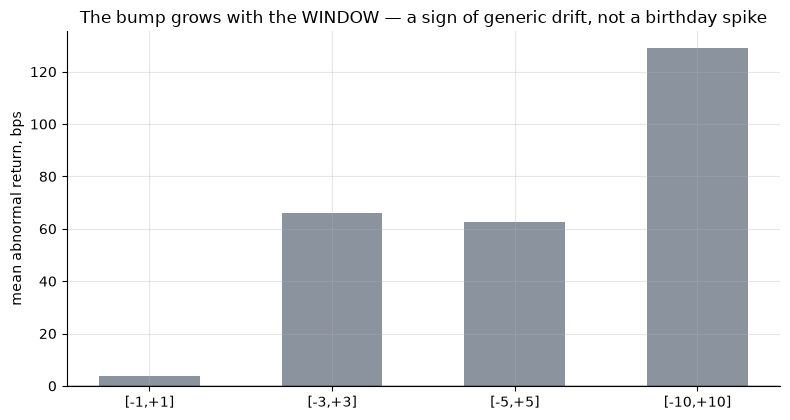

mean CAR by window (bps): [3.7, 66.0, 62.7, 129.0]


In [3]:
sweep = [('[-1,+1]', 3.7), ('[-3,+3]', 66.0), ('[-5,+5]', 62.7), ('[-10,+10]', 129.0)]
if HAVE_REAL:
    tab = st.window_sweep(AR, IPOS, [(1,1),(3,3),(5,5),(10,10)])
    labs = list(tab['window']); vals = list(tab['mean_car_bps'])
else:
    labs = [s[0] for s in sweep]; vals = [s[1] for s in sweep]
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(labs, vals, color=GREY, width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean abnormal return, bps')
ax.set_title('The bump grows with the WINDOW — a sign of generic drift, not a birthday spike')
plt.tight_layout(); plt.show()
print('mean CAR by window (bps):', [round(v,1) for v in vals])

The tell: the tight **3-day** window around the actual date is **+3.7 bps** — essentially zero. The number only grows as we widen the window to 21 days, which just captures more of the stock's general upward drift. A real *birthday* spike would sit tight on the date; this doesn't.

## 5 · The verdict

- **Signal — None.** Mean birthday CAR **+62.75 bps** at *t* 1.36 (median +12.0 bps, only 50.6% positive), and a random date does *better* (*p* = 0.648). No birthday effect.
- **Tradability — Mirage.** The tiny positive average is just these survivors beating the market in any window; there is no date-specific edge to harvest.

## 6 · Could you actually trade it?

No. Even the un-adjusted average is a fraction of a percent, it isn't statistically real, and it evaporates the moment you compare it to a random date. Add a round-trip cost each year and you are paying to collect noise. The birthday is a story, not a signal.

## 7 · Going further 🚪

- **The launch, not the birthday.** [219 IPO-Pop](../../219-ipo-pop/) tackles the *first-day* pop and the long-run hangover — a different (and better documented) object.
- **Other calendar folklore.** [89 Turn-of-the-Month](../../89-turn-of-the-month/), [95 Holiday-Cheer](../../95-holiday-cheer/), [544 Oyster-R-Months](../../544-oyster-r-months/) test market-wide calendar dates with the same placebo discipline.

*Think there's a real birthday effect on some other universe? Fork this, swap the basket, and show the tight `[-1,+1]` window clearing t = 2 against the random-anchor placebo.*